Carregando os dados e separando df's de treino e de teste.

In [2]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "dengue_pipeline").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))

from dengue_pipeline import DengueDataCleaner
from dengue_pipeline.models import GradientBoostingDiseaseClassifier
from dengue_pipeline.paths import MODELS_DIR, MODEL_FIGURES_DIR

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def salvar_modelo(modelo, nome_arquivo):
    caminho = MODELS_DIR / nome_arquivo
    joblib.dump(modelo, caminho)
    print(f"Modelo salvo em: {caminho}")
    return caminho

def plotar_importancias(importancias, titulo, nome_arquivo, top_n=30):
    dados = importancias.sort_values(ascending=False).head(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(dados.index, dados.values, color="#2563eb", alpha=0.9)
    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Importância")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.22)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    caminho = MODEL_FIGURES_DIR / nome_arquivo
    fig.savefig(caminho, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Gráfico salvo em: {caminho}")

cleaner = DengueDataCleaner()
df = cleaner.transformar_ml()

df_train = df[(df["notification_year"].isin([2017, 2018])) | ((df["notification_year"] == 2019) & (df["notification_month"] <= 5))].copy()
df_test = df[(df["notification_year"] == 2019) & (df["notification_month"] >= 6)].copy()

print("Treino:", df_train.shape)
print("Teste:", df_test.shape)

print("Proporção treino:", (len(df_train) / len(df))*100)
print("Proporção teste:", (len(df_test) / len(df))*100)

df.columns

c:\Users\dudun\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Treino: (2345627, 111)
Teste: (528608, 111)
Proporção treino: 81.60874110850365
Proporção teste: 18.391258891496346


Index(['age_years', 'education_level', 'occupation_code', 'residence_state',
       'residence_municipality', 'residence_health_region',
       'notification_year', 'notification_month', 'notif_municipality',
       'notif_health_region',
       ...
       'arthritis_and_joint_pain', 'arthritis_and_petechiae',
       'arthritis_and_retro_orbital_pain', 'joint_pain_and_petechiae',
       'joint_pain_and_retro_orbital_pain', 'petechiae_and_retro_orbital_pain',
       'number_of_symptoms', 'number_of_important_symptoms', 'pregnancy',
       'pregnancy_informed'],
      dtype='str', length=111)

Definindo o target e eliminando colunas que não são apropriadas para o modelo

In [3]:
target = "final_classification"

y_train = df_train[target]
y_test = df_test[target]

cols_remove = ['final_classification']

X_train = df_train.drop(columns = cols_remove)
X_test = df_test.drop(columns=cols_remove)

X_train = X_train.select_dtypes(include=["number"])
X_test = X_test[X_train.columns]

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [4]:
administrative_features = [
    "notification_year",
    "notification_month",
    "symptom_epi_year",
    "notif_municipality",
    "notif_health_region",
    "health_facility",
]

X_train = X_train.drop(columns=administrative_features, errors="ignore")
X_test = X_test.drop(columns=administrative_features, errors="ignore")

Implementação de Regressão Logistica 

In [ ]:
#Regressao Logistica - testando...
from sklearn.linear_model import LogisticRegression

modelo_logistic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_logistic.fit(X_train, y_train)

y_pred_logistic = modelo_logistic.predict(X_test)

print(classification_report(y_test, y_pred_logistic))
print(confusion_matrix(y_test, y_pred_logistic))

salvar_modelo(modelo_logistic, "logistic_regression.joblib")
importancias_logistic = pd.Series(
    modelo_logistic.named_steps["classifier"].coef_[0],
    index=X_train.columns,
).abs().sort_values(ascending=False)
plotar_importancias(
    importancias_logistic,
    "Regressão Logística - Top 30 Features",
    "logistic_regression_feature_importance.png",
)

Implementação de XGBoost

In [ ]:
# Teste da classe adaptada usando XGBoost.
# O XGBoost trata valores ausentes nativamente.
modelo_xgb = GradientBoostingDiseaseClassifier(
    model="xgb",
    fast_train=False,
    device="cuda"
)

modelo_xgb.fit(
    X_train,
    y_train,
    n_trials=200,
    tuning_sample_size=200_000,
)
y_pred_xgb = modelo_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

resultados_limiares_xgb = modelo_xgb.evaluate(
    X_test,
    y_test,
    thresholds=[0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80],
)
display(resultados_limiares_xgb)

salvar_modelo(modelo_xgb, "xgboost.joblib")
importancias_xgb = modelo_xgb.feature_importance(importance_type="gain")
plotar_importancias(
    importancias_xgb,
    "XGBoost - Top 30 Features por Ganho",
    "xgboost_feature_importance.png",
)

Optuna usando amostra estratificada de 200,000 registros.


Best trial: 125. Best value: 0.879626: 100%|██████████| 200/200 [22:09<00:00,  6.65s/it]


Melhor average_precision: 0.8796
Melhores parâmetros: {'n_estimators': 500, 'learning_rate': 0.068505776505835, 'max_depth': 8, 'subsample': 0.9278016629631768, 'colsample_bytree': 0.7310692069130846, 'reg_alpha': 0.12242116344779436, 'reg_lambda': 0.02062894935985779, 'num_leaves': 245, 'min_child_samples': 20}
              precision    recall  f1-score   support

         0.0       0.53      0.87      0.66    218981
         1.0       0.84      0.46      0.60    309627

    accuracy                           0.63    528608
   macro avg       0.69      0.67      0.63    528608
weighted avg       0.71      0.63      0.62    528608

[[190926  28055]
 [166390 143237]]
 threshold  accuracy  precision  recall     f1
    0.0300    0.6300     0.6143  0.9897 0.7581
    0.0500    0.6643     0.6420  0.9652 0.7711
    0.0700    0.6857     0.6638  0.9392 0.7778
    0.1000    0.7004     0.6857  0.9020 0.7791
    0.1500    0.7008     0.7093  0.8289 0.7645
    0.2000    0.6983     0.7297  0.7703 0.

,threshold,accuracy,precision,recall,f1
0,0.03,0.630004,0.614315,0.989675,0.758074
1,0.05,0.664320,0.641979,0.965174,0.771080
2,0.07,0.685709,0.663765,0.939175,0.777810
3,0.10,0.700430,0.685708,0.901982,0.779115
4,0.15,0.700805,0.709321,0.828872,0.764451
5,0.20,0.698330,0.729721,0.770278,0.749451
6,0.25,0.692218,0.747215,0.717160,0.731879
7,0.30,0.684957,0.765051,0.666977,0.712655
8,0.40,0.663961,0.801510,0.566620,0.663902
9,0.50,0.632157,0.836215,0.462611,0.595680


Modelo salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\artifacts\models\lightgbm.joblib


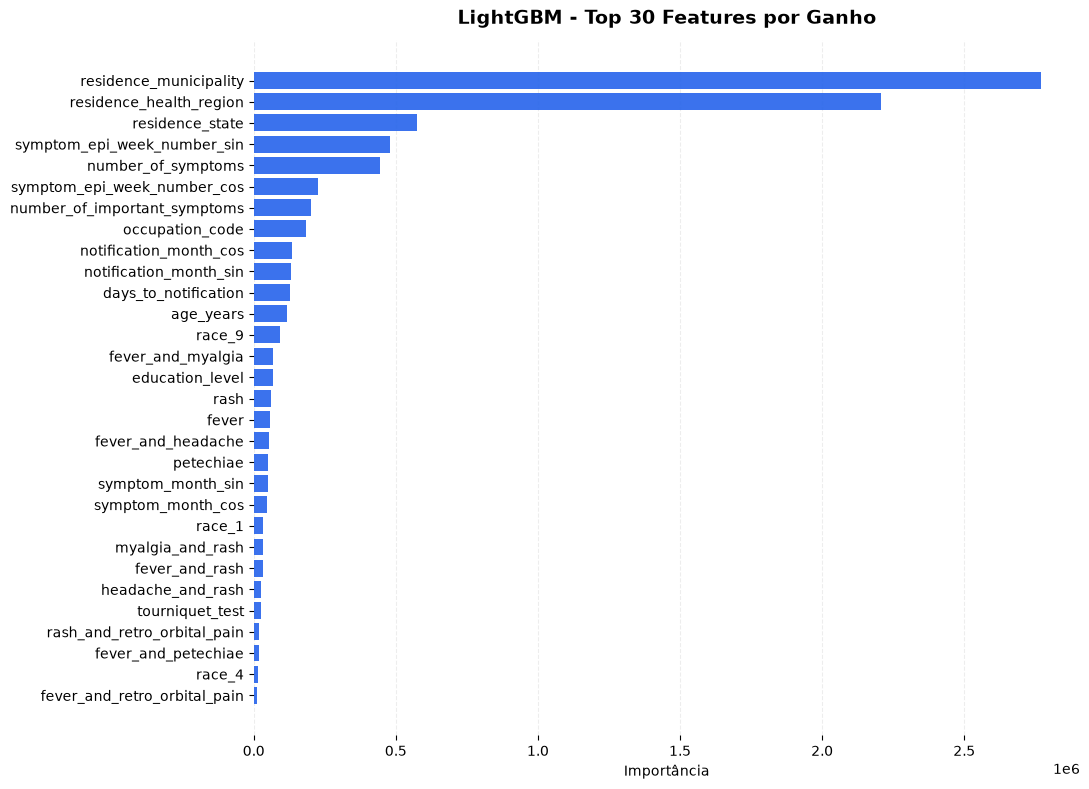

Gráfico salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\reports\figures\modeling\lightgbm_feature_importance.png


In [5]:
# Teste da classe adaptada usando LightGBM.
# O LightGBM trata valores ausentes nativamente.
modelo_lgb = GradientBoostingDiseaseClassifier(
    model="lgbm",
    fast_train=False,
    device="cpu"
)

modelo_lgb.fit(
    X_train,
    y_train,
    n_trials=200,
    tuning_sample_size=200_000,
)
y_pred_lgb = modelo_lgb.predict(X_test)

print(classification_report(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))

resultados_limiares_lgb = modelo_lgb.evaluate(
    X_test,
    y_test,
    thresholds=[0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80],
)
display(resultados_limiares_lgb)

salvar_modelo(modelo_lgb, "lightgbm.joblib")
importancias_lgb = modelo_lgb.feature_importance(importance_type="gain")
plotar_importancias(
    importancias_lgb,
    "LightGBM - Top 30 Features por Ganho",
    "lightgbm_feature_importance.png",
)

Implementação de Arvore de Decisao

              precision    recall  f1-score   support

         0.0       0.50      0.89      0.64    218981
         1.0       0.83      0.37      0.51    309627

    accuracy                           0.59    528608
   macro avg       0.66      0.63      0.57    528608
weighted avg       0.69      0.59      0.56    528608

[[195661  23320]
 [195937 113690]]
Modelo salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\artifacts\models\decision_tree.joblib


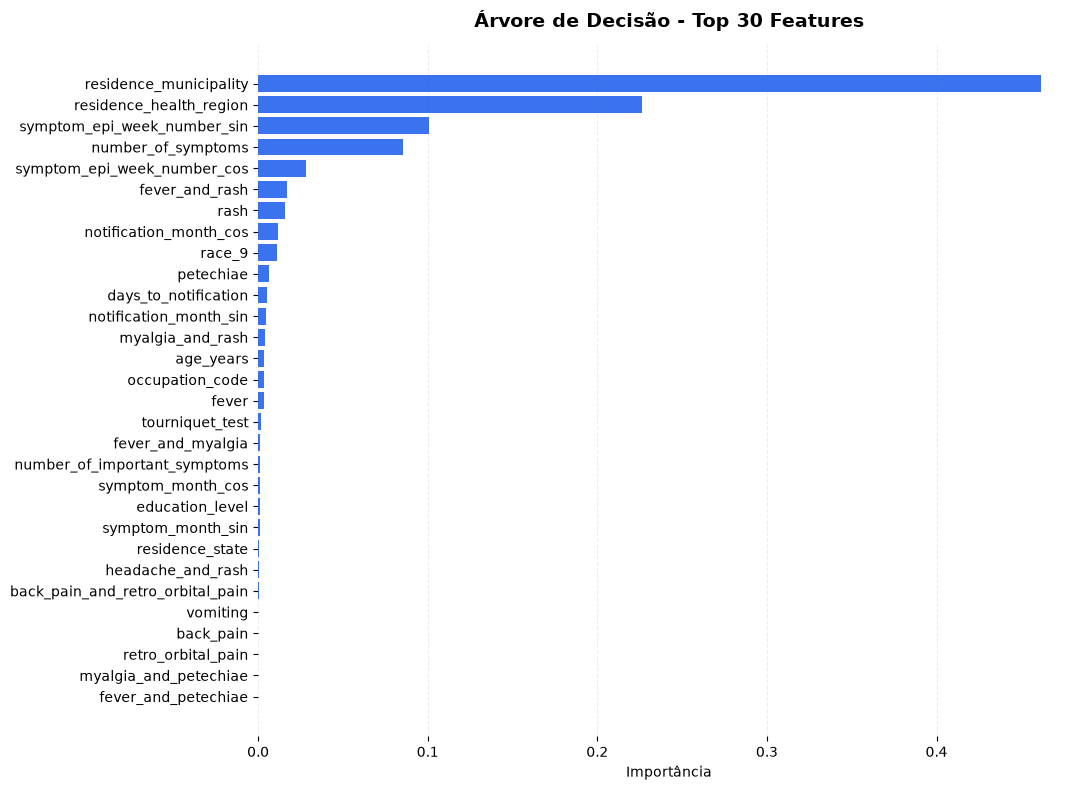

Gráfico salvo em: C:\Users\dudun\OneDrive\Desktop\Dengue\reports\figures\modeling\decision_tree_feature_importance.png


In [6]:
from sklearn.tree import DecisionTreeClassifier

modelo_decision_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_decision_tree.fit(X_train, y_train)

y_pred_decision_tree = modelo_decision_tree.predict(X_test)

print(classification_report(y_test, y_pred_decision_tree))
print(confusion_matrix(y_test, y_pred_decision_tree))

salvar_modelo(modelo_decision_tree, "decision_tree.joblib")
importancias_decision_tree = pd.Series(
    modelo_decision_tree.named_steps["classifier"].feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)
plotar_importancias(
    importancias_decision_tree,
    "Árvore de Decisão - Top 30 Features",
    "decision_tree_feature_importance.png",
)